# Phase 2 — U-Net Specialist Baseline
**Project:** Can LoRA-Adapted SAM Match Specialist Polyp Networks?

This notebook trains the U-Net specialist baseline:
- ResNet-34 encoder (ImageNet pre-trained)
- Combined Dice + BCE loss
- AdamW + cosine LR schedule
- Early stopping on validation Dice
- Evaluated on all 5 splits (seen + unseen)

## 1. Setup

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO = '/content/msu2026summer_final_project'
    if not os.path.exists(REPO):
        !git clone --quiet https://github.com/palism1/msu2026summer_final_project.git {REPO}
    %cd {REPO}
    !git fetch --quiet origin && git reset --hard origin/main
    !find . -name '__pycache__' -type d -exec rm -rf {} + 2>/dev/null; true
    !pip install -q -r requirements.txt

repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Download data in setup so this works even if Colab loads a cached notebook
import gdown, shutil, zipfile
from pathlib import Path

DATA_ROOT = Path('data/polyp')
DATA_ROOT.mkdir(parents=True, exist_ok=True)

def _dl(file_id, zip_name):
    target = DATA_ROOT / zip_name.replace('.zip', '')
    if target.exists():
        print(f'{target.name}: already present'); return
    zip_path = f'/tmp/{zip_name}'
    print(f'Downloading {target.name}...')
    gdown.download(id=file_id, output=zip_path, quiet=False, fuzzy=True)
    tmp = Path(f'/tmp/extract_{target.name}')
    tmp.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(tmp)
    extracted = [p for p in tmp.iterdir() if not p.name.startswith('__')]
    if len(extracted) == 1 and extracted[0].is_dir():
        shutil.move(str(extracted[0]), str(target))
    else:
        target.mkdir(exist_ok=True)
        for p in extracted: shutil.move(str(p), str(target / p.name))
    print(f'Done -> {target}')

_dl('1YiGHLw4iTvKdvbT6MgwO9zcCv8zJ_Bnb', 'TrainDataset.zip')
_dl('1Y2z7FD5p5y31vkZwQQomXFRB0HutHyao', 'TestDataset.zip')

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}  |  GPU: {torch.cuda.get_device_name(0) if device=="cuda" else "N/A"}')

/content/msu2026summer_final_project
HEAD is now at c6dd853 Fix RandomScale breaking fixed output size in train transform
TrainDataset: already present
TestDataset: already present
Device: cuda  |  GPU: Tesla T4


## 2. Data

In [2]:
import gdown, shutil, zipfile
from pathlib import Path

DATA_ROOT = Path('data/polyp')
DATA_ROOT.mkdir(parents=True, exist_ok=True)

TRAIN_ID = '1YiGHLw4iTvKdvbT6MgwO9zcCv8zJ_Bnb'
TEST_ID  = '1Y2z7FD5p5y31vkZwQQomXFRB0HutHyao'

def download_and_extract(file_id, zip_name):
    folder_name = zip_name.replace('.zip', '')
    target = DATA_ROOT / folder_name
    zip_path = f'/tmp/{zip_name}'
    if target.exists():
        n = len(list(target.rglob('*.jpg')) + list(target.rglob('*.png')))
        print(f'{folder_name}: already present ({n} files)')
        return
    print(f'Downloading {folder_name}...')
    gdown.download(id=file_id, output=zip_path, quiet=False, fuzzy=True)
    print('Extracting...')
    tmp = Path(f'/tmp/extract_{folder_name}')
    tmp.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(tmp)
    extracted = [p for p in tmp.iterdir() if not p.name.startswith('__')]
    if len(extracted) == 1 and extracted[0].is_dir():
        shutil.move(str(extracted[0]), str(target))
    else:
        target.mkdir(exist_ok=True)
        for item in extracted:
            shutil.move(str(item), str(target / item.name))
    print(f'Done -> {target}')

download_and_extract(TRAIN_ID, 'TrainDataset.zip')
download_and_extract(TEST_ID,  'TestDataset.zip')
print(f'Data root: {DATA_ROOT.resolve()}')

TrainDataset: already present (2900 files)
TestDataset: already present (1596 files)
Data root: /content/msu2026summer_final_project/data/polyp


In [3]:
from pathlib import Path
from torch.utils.data import DataLoader
from src.data import PolypDataset, build_splits, get_train_transform, get_val_transform

DATA_ROOT = Path('data/polyp')
IMG_SIZE  = 352
SEED      = 42
BATCH     = 16

splits = build_splits(DATA_ROOT, seed=SEED)

train_ds = PolypDataset(
    splits['train']['image_paths'],
    splits['train']['mask_paths'],
    transform=get_train_transform(IMG_SIZE),
)
val_ds = PolypDataset(
    splits['seen_kvasir']['image_paths'] + splits['seen_clinicdb']['image_paths'],
    splits['seen_kvasir']['mask_paths']  + splits['seen_clinicdb']['mask_paths'],
    transform=get_val_transform(IMG_SIZE),
)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} images ({len(train_loader)} batches)')
print(f'Val:   {len(val_ds)} images ({len(val_loader)} batches)')

Train: 1450 images (91 batches)
Val:   162 images (11 batches)


## 3. Model

In [4]:
from src.models import build_unet
from src.models.unet import count_parameters

model = build_unet(encoder='resnet34', encoder_weights='imagenet').to(device)
params = count_parameters(model)
print(f'U-Net (ResNet-34 encoder)')
print(f'  Total parameters:     {params["total"]:>12,}')
print(f'  Trainable parameters: {params["trainable"]:>12,}')

# Quick forward pass check
import torch
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    out = model(dummy)
print(f'  Forward pass OK: input {list(dummy.shape)} → output {list(out.shape)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


U-Net (ResNet-34 encoder)
  Total parameters:       24,436,369
  Trainable parameters:   24,436,369
  Forward pass OK: input [2, 3, 352, 352] → output [2, 1, 352, 352]


## 4. Training

In [5]:
import time, os
import numpy as np
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm
from src.metrics import MetricTracker

# ---------- loss ----------
def dice_bce_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    bce = nn.functional.binary_cross_entropy_with_logits(logits, targets)
    inter = (probs * targets).sum(dim=(1, 2, 3))
    dice = 1 - (2 * inter + eps) / (probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) + eps)
    return bce + dice.mean()

# ---------- hyperparameters ----------
EPOCHS   = 100
LR       = 1e-4
PATIENCE = 10
CKPT_DIR = Path('checkpoints/unet/seed42')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ---------- training loop ----------
history = {'train_loss': [], 'val_dice': [], 'val_iou': []}
best_dice, patience_count = 0.0, 0

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    epoch_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch:03d} train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = dice_bce_loss(model(imgs), masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)

    # --- validate ---
    model.eval()
    tracker = MetricTracker()
    with torch.no_grad():
        for imgs, masks in val_loader:
            probs = torch.sigmoid(model(imgs.to(device))).cpu().numpy()
            gt    = masks.numpy()
            for i in range(len(probs)):
                tracker.update(probs[i, 0], gt[i, 0])

    scores = tracker.compute()
    scheduler.step()

    history['train_loss'].append(epoch_loss)
    history['val_dice'].append(scores['dice'])
    history['val_iou'].append(scores['iou'])

    print(f'Epoch {epoch:03d} | loss={epoch_loss:.4f} | val_dice={scores["dice"]:.4f} | val_iou={scores["iou"]:.4f}')

    if scores['dice'] > best_dice:
        best_dice = scores['dice']
        patience_count = 0
        torch.save(model.state_dict(), CKPT_DIR / 'best.pt')
        print(f'  ↑ New best — checkpoint saved')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest val Dice: {best_dice:.4f}')

Epoch 001 train:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 001 | loss=1.0953 | val_dice=0.7007 | val_iou=0.5843
  ↑ New best — checkpoint saved


Epoch 002 train:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 002 | loss=0.7786 | val_dice=0.7873 | val_iou=0.6960
  ↑ New best — checkpoint saved


Epoch 003 train:   0%|          | 0/91 [00:00<?, ?it/s]

...

Epoch 073 | loss=0.0773 | val_dice=0.9095 | val_iou=0.8549


Epoch 074 train:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 074 | loss=0.0759 | val_dice=0.9104 | val_iou=0.8538


Epoch 075 train:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 075 | loss=0.0747 | val_dice=0.9070 | val_iou=0.8498
Early stopping at epoch 75

Best val Dice: 0.9121


## 5. Training Curves

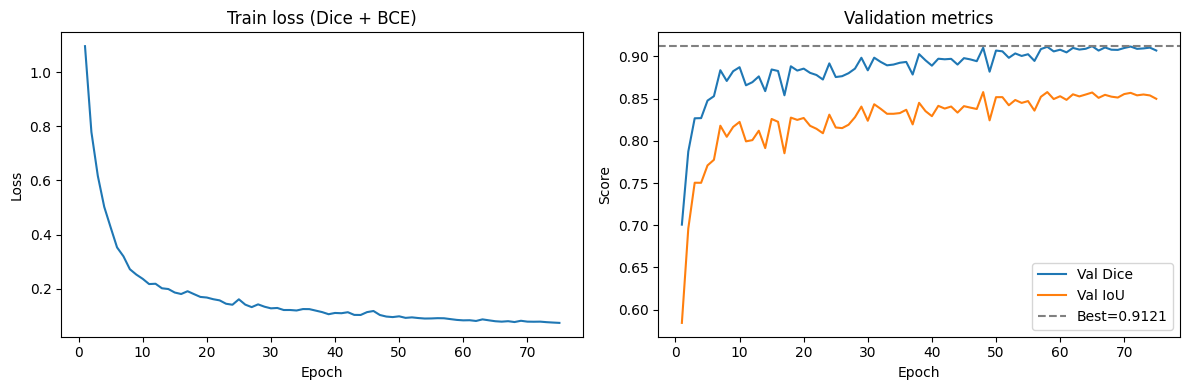

In [6]:
import matplotlib.pyplot as plt

epochs_run = range(1, len(history['val_dice']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_run, history['train_loss'])
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Train loss (Dice + BCE)')

ax2.plot(epochs_run, history['val_dice'],  label='Val Dice')
ax2.plot(epochs_run, history['val_iou'],   label='Val IoU')
ax2.axhline(best_dice, linestyle='--', color='gray', label=f'Best={best_dice:.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score'); ax2.set_title('Validation metrics')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Full Evaluation (Seen + Unseen)

In [14]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_DIR / 'best.pt', map_location=device))
model.eval()

val_transform = get_val_transform(IMG_SIZE)

split_labels = {
    'Seen — Kvasir':        'seen_kvasir',
    'Seen — CVC-ClinicDB':  'seen_clinicdb',
    'Unseen — CVC-ColonDB': 'cvc_colondb',
    'Unseen — ETIS-Larib':  'etis_larib',
    'Unseen — CVC-300':     'cvc_300',
}

print(f'{"Split":<26} {"mDice":>7} {"mIoU":>7} {"MAE":>7} {"wFm":>7} {"Sm":>7} {"Em":>7}')
print('-' * 75)

results = {}
for label, key in split_labels.items():
    if key not in splits:
        print(f'{label:<26} -- not downloaded yet --')
        continue
    ds = PolypDataset(splits[key]['image_paths'], splits[key]['mask_paths'], transform=val_transform)
    loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    tracker = MetricTracker()
    with torch.no_grad():
        for imgs, masks in loader:
            probs = torch.sigmoid(model(imgs.to(device))).cpu().numpy()
            for i in range(len(probs)):
                tracker.update(probs[i, 0], masks[i, 0].numpy())
    sc = tracker.compute()
    results[key] = sc
    print(f'{label:<26} {sc["dice"]:>7.4f} {sc["iou"]:>7.4f} {sc["mae"]:>7.4f} '
          f'{sc["wfm"]:>7.4f} {sc["sm"]:>7.4f} {sc["em"]:>7.4f}')

if 'seen_kvasir' in results and 'seen_clinicdb' in results:
    seen_dice = (results['seen_kvasir']['dice'] + results['seen_clinicdb']['dice']) / 2
    unseen_keys = [k for k in ('cvc_colondb', 'etis_larib', 'cvc_300') if k in results]
    if unseen_keys:
        unseen_dice = np.mean([results[k]['dice'] for k in unseen_keys])
        print(f'\nGeneralization gap (seen − unseen mDice): {seen_dice - unseen_dice:+.4f}')

Split                        mDice    mIoU     MAE     wFm      Sm      Em
---------------------------------------------------------------------------
Seen — Kvasir               0.9109  0.8540  0.0274  0.9180  0.9229  0.9315
Seen — CVC-ClinicDB         0.9141  0.8625  0.0105  0.9126  0.9388  0.9526
Unseen — CVC-ColonDB        0.7821  0.6997  0.0366  0.7912  0.8541  0.8557
Unseen — ETIS-Larib         0.7112  0.6297  0.0266  0.7044  0.8253  0.7791
Unseen — CVC-300            0.8382  0.7572  0.0130  0.8224  0.8958  0.9017

Generalization gap (seen − unseen mDice): +0.1354


## Save Checkpoint to Google Drive

Persists `best.pt` so `05_benchmark.ipynb` can load it in a separate session.

In [ ]:
if IN_COLAB:
    from google.colab import drive
    import shutil
    drive.mount('/content/drive', force_remount=False)

    _model_name = 'unet'
    DRIVE_CKPT_DIR = Path('/content/drive/MyDrive/msu2026_checkpoints') / _model_name / f'seed{SEED}'
    DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy(CKPT_DIR / 'best.pt', DRIVE_CKPT_DIR / 'best.pt')
    print(f'Checkpoint backed up -> {DRIVE_CKPT_DIR / "best.pt"}')
else:
    print('Not running in Colab — skipping Drive backup (checkpoint already at', CKPT_DIR / 'best.pt', ')')

## 7. Prediction Visualisation



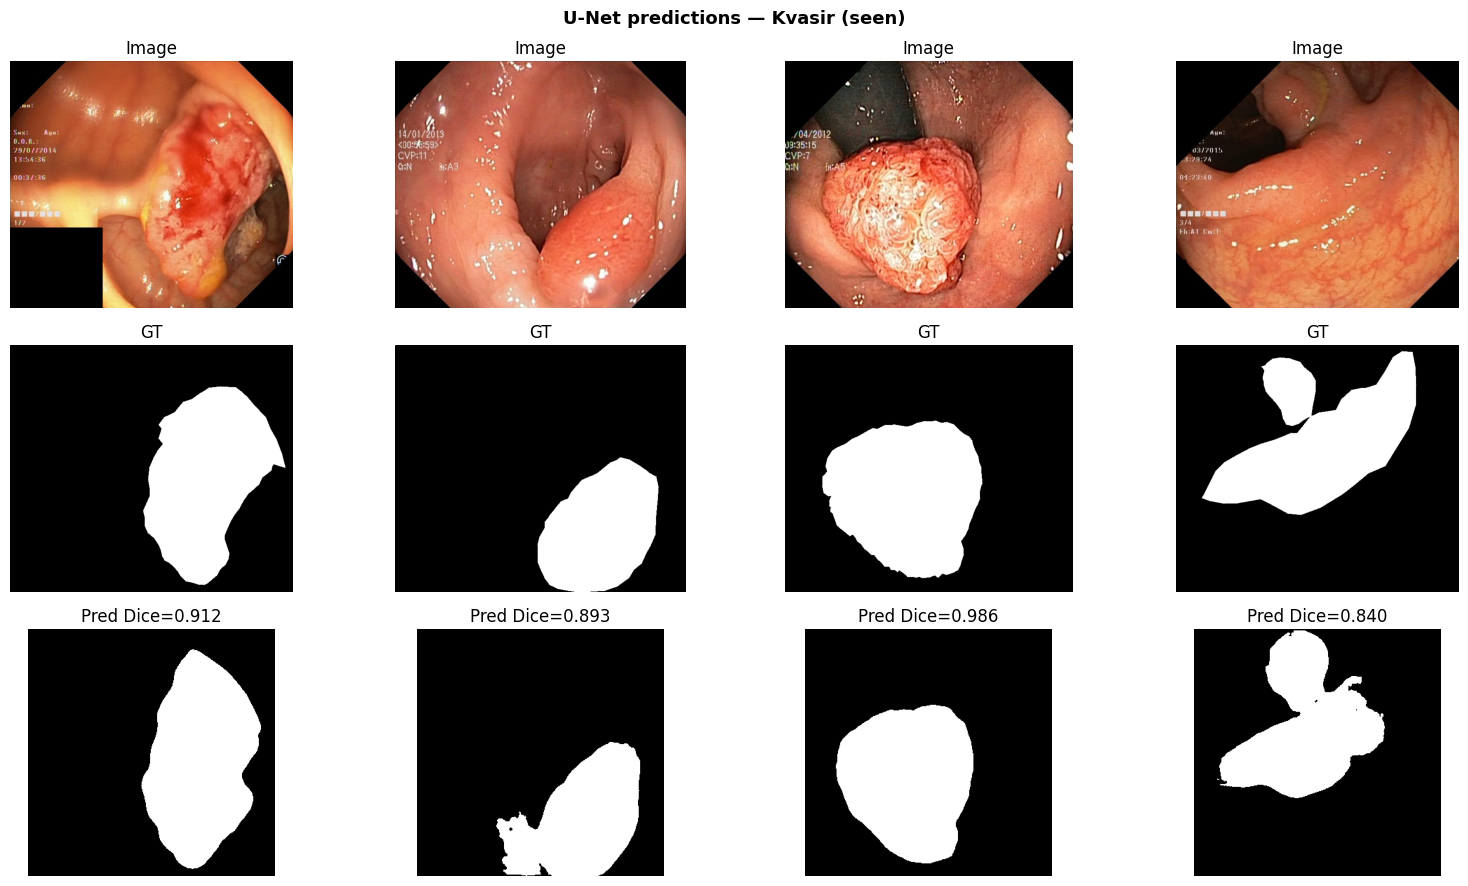

In [16]:
from PIL import Image

show_predictions(
    model,
    splits['seen_kvasir']['image_paths'][:4],
    splits['seen_kvasir']['mask_paths'][:4],
    'U-Net predictions — Kvasir (seen)',
    device=device
)


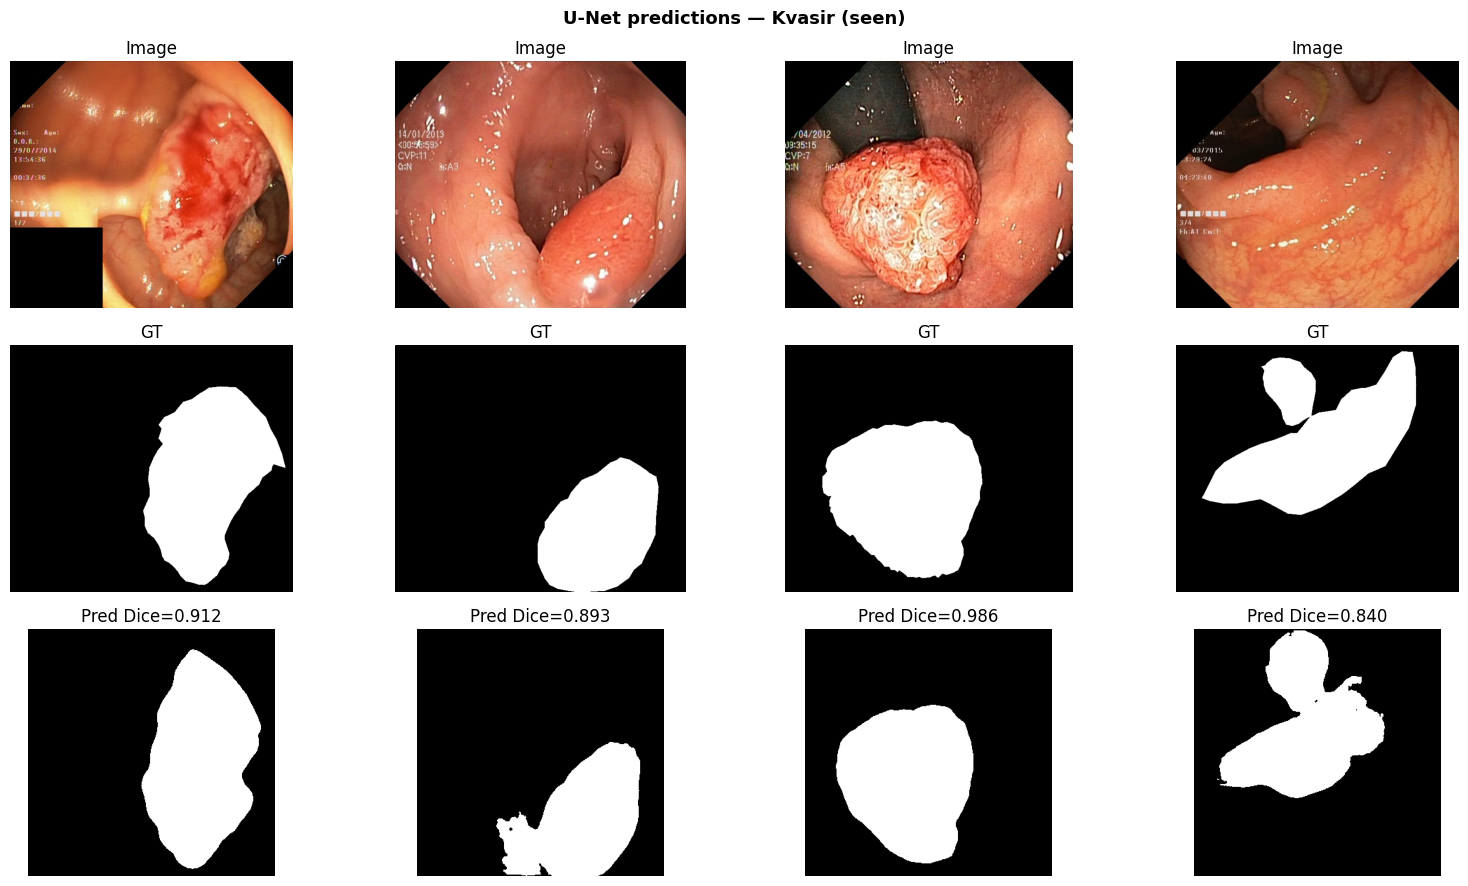

In [17]:
from src.metrics import dice_score

def show_predictions(model, image_paths, mask_paths, title, n=4, device='cpu'):
    fig, axes = plt.subplots(3, n, figsize=(4*n, 9))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    model.eval()
    transform = get_val_transform(IMG_SIZE)

    for i in range(n):
        raw_img = np.array(Image.open(image_paths[i]).convert('RGB'))
        raw_msk = (np.array(Image.open(mask_paths[i]).convert('L')) > 127).astype(np.float32)

        aug = transform(image=raw_img, mask=raw_msk)
        inp = aug['image'].unsqueeze(0).to(device)
        with torch.no_grad():
            prob = torch.sigmoid(model(inp))[0, 0].cpu().numpy()
        pred_bin = (prob >= 0.5).astype(np.float32)
        d = dice_score(pred_bin, aug['mask'].numpy())

        axes[0, i].imshow(raw_img); axes[0, i].set_title('Image');    axes[0, i].axis('off')
        axes[1, i].imshow(raw_msk, cmap='gray'); axes[1, i].set_title('GT'); axes[1, i].axis('off')
        axes[2, i].imshow(pred_bin, cmap='gray'); axes[2, i].set_title(f'Pred Dice={d:.3f}'); axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(
    model,
    splits['seen_kvasir']['image_paths'][:4],
    splits['seen_kvasir']['mask_paths'][:4],
    'U-Net predictions — Kvasir (seen)',
    device=device
)

## Phase 2 Summary

| Deliverable | Status |
|---|---|
| U-Net (ResNet-34) baseline trained | ✅ |
| Best checkpoint saved | ✅ |
| Seen/unseen evaluation table | ✅ |
| Generalization gap measured | ✅ |

**Next:** `03_sam_lora.ipynb` — parameter-efficient adaptation of SAM.